In [1]:
## Patient class: run this first. Updated on 8/28/2019

class Patient:
    def __init__(self, subjectID, mrn_or_csn, today, consent_datetime, admit_dt, icu_admit_dt, icu_discharge_dt, discharge_dt, drug_admin_pt, total_nights,
                 subject_wgt_dt, subject_wgt, sorted_gfr_dts, sorted_gfr_vals, sorted_creat_dts, sorted_creat_vals, gfr_baseline, gfr_baseline_dt, 
                 creat_baseline, creat_baseline_dt, datenumsBP_limited, bp1_limited, bp2_limited, datenumsHR_limited, hr_vals_limited, 
                 datenumsO2_limited, o2_vals_limited, datenumsTMP_limited, tmp_limited, datenumsUrine_limited, urine_limited, AEs, 
                 daily_hr_baseline, daily_systolic_baseline, daily_o2_baseline):
        
        self.ID = subjectID
        self.mrn = mrn_or_csn
        self.dt_created = today
        self.consent = consent_datetime
        self.admit_dt = admit_dt
        self.discharge_dt = discharge_dt
        self.icu_admit_dt = icu_admit_dt
        self.icu_discharge_dt = icu_discharge_dt
        
        self.drug_data = drug_admin_pt
        self.nights_of_drug = total_nights
        
        self.weight_dt = subject_wgt_dt
        self.weight = subject_wgt
        
        self.full_gfr_dts = sorted_gfr_dts
        self.full_gfr_vals = sorted_gfr_vals
        self.full_creat_dts = sorted_creat_dts
        self.full_creat_vals = sorted_creat_vals
        
        if icu_admit_dt != None and icu_discharge_dt != None:
            self.gfr_dts = []
            self.gfr_vals = []
            for ii in range(len(self.full_gfr_dts)):
                x = self.full_gfr_dts[ii]
                if x >= self.icu_admit_dt and x <= self.icu_discharge_dt:
                    self.gfr_dts.append(x)
                    self.gfr_vals.append(self.full_gfr_vals[ii])
                
            self.creat_dts = []
            self.creat_vals = []
            for ii in range(len(self.full_creat_dts)):
                x = self.full_creat_dts[ii]
                if x >= self.icu_admit_dt and x <= self.icu_discharge_dt:
                    self.creat_dts.append(x)
                    self.creat_vals.append(self.full_creat_vals[ii])
        else:
            self.gfr_dts    = None
            self.gfr_vals   = None
            self.creat_dts  = None
            self.creat_vals = None
        
        self.gfr_baseline1 = gfr_baseline
        self.gfr_baseline1_dt = gfr_baseline_dt
        self.creat_baseline1 = creat_baseline
        self.creat_baseline1_dt = creat_baseline_dt
        
        self.datenums_BP = datenumsBP_limited
        self.systolic = bp1_limited
        self.diastolic = bp2_limited
        self.datenums_HR = datenumsHR_limited
        self.hr = hr_vals_limited
        self.datenums_O2 = datenumsO2_limited
        self.o2 = o2_vals_limited
        self.datenums_tmp = datenumsTMP_limited
        self.tmp = tmp_limited
        self.datenums_urine = datenumsUrine_limited
        self.urine = urine_limited
        
        self.raw_AEs = AEs
        
        self.hr_baseline = daily_hr_baseline
        self.systolic_baseline = daily_systolic_baseline
        self.o2_baseline = daily_o2_baseline
        
    def plot_gfr(self):
    
        if self.gfr_vals != None and len(self.gfr_vals) > 0:
    
            fig, ax = plt.subplots()
            plt.plot(self.gfr_dts, self.gfr_vals)
    
            if self.gfr_baseline1 != None:
                plt.plot(self.gfr_baseline1_dt, self.gfr_baseline1, marker='o')
    
            ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))
            ax.set_title(self.ID + ' GFR', fontdict={'fontsize': 10, 'fontweight': 'medium'})
            
            if self.icu_admit_dt != None and self.icu_discharge_dt != None:
                plt.axvline(self.icu_admit_dt)
                plt.axvline(self.icu_discharge_dt)
            
    #def plot_creatinine(self):
    def plot_creatinine(self):
    
        if self.creat_vals != None and len(self.creat_vals) > 0:
    
            fig, ax = plt.subplots()
            plt.plot(self.creat_dts, self.creat_vals)
    
            if self.creat_baseline1 != None:
                plt.plot(self.creat_baseline1_dt, self.creat_baseline1, marker='o')
    
            ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))
            ax.set_title(self.ID + ' Creatinine', fontdict={'fontsize': 10, 'fontweight': 'medium'})
        
            if self.icu_admit_dt != None and self.icu_discharge_dt != None:
                plt.axvline(self.icu_admit_dt)
                plt.axvline(self.icu_discharge_dt)
            
    def check_gfr(self):
        
        if self.gfr_baseline1 != None and self.gfr_vals != None :
            gfr_drop_below_50p1 = False
            for gfr_val,gfr_dt in zip(self.gfr_vals, self.gfr_dts):
                if gfr_val < 0.5*self.gfr_baseline1 and gfr_dt > self.gfr_baseline1_dt:
                    gfr_drop_below_50p1 = True
                    return gfr_drop_below_50p1
            return gfr_drop_below_50p1
        else:
            return None
        
        
    def check_creatinine(self):
    
        if self.creat_baseline1 != None and self.creat_vals != None:
            creat_above_baseline = False 
            for creat_val, creat_dt in zip(self.creat_vals, self.creat_dts):
                if creat_val > 2*self.creat_baseline1 and creat_dt > self.creat_baseline1_dt:
                    creat_above_baseline = True
                    return creat_above_baseline
            return creat_above_baseline
    
        else:
            return None
        
    def check_urine(self):
        
        if self.icu_admit_dt != None and self.icu_discharge_dt != None and self.weight != None:
            
            self.urine_hosp_dts = []
            self.urine_hosp = []
            for ii in range(len(self.datenums_urine)):
                x = md.num2date( self.datenums_urine[ii] ).replace(tzinfo=None)
                if x >= self.icu_admit_dt and x <= self.icu_discharge_dt:
                    if not np.isnan(self.urine[ii]):
                        self.urine_hosp_dts.append(x)
                        self.urine_hosp.append(self.urine[ii])
                    
            # look for 12 hour period following each data point
            for ii in range(len(self.urine_hosp_dts)-1):
                avg_urine = 100000
                vals_to_avg = []
                current_dts = []
                
                start_time = self.urine_hosp_dts[ii]
                start_dex = ii
                
                vals_to_avg.append(self.urine_hosp[ii])
                current_dts.append(self.urine_hosp_dts[ii])
                
                jj = ii + 1
                while jj < len(self.urine_hosp_dts):
                    
                    if self.urine_hosp_dts[jj] <= ( start_time + dt.timedelta(hours=12)):
                        vals_to_avg.append(self.urine_hosp[jj])
                        current_dts.append(self.urine_hosp_dts[jj])
                    else:
                        break
                    
                    jj = jj + 1
                
                last_time = current_dts[-1]
                #elapsedTime = 12#last_time - start_time
                hours_elapsed = 12   #elapsedTime.total_seconds()/3600.0
                
                avg_urine = sum(vals_to_avg)/(self.weight*hours_elapsed)
                # len = 1 means there was a gap of 12 hours w/ no urine
                if (len(current_dts) == 1 and ii < len(self.urine_hosp_dts)-2) or avg_urine < .5: 
                    
                    fig, ax = plt.subplots()
                    plt.plot(current_dts, vals_to_avg)
                    ax.xaxis.set_major_formatter(DateFormatter('%m-%d \n %H'))
                    plt.show()
                    
                    if len(current_dts) == 1:
                        return 'tentative'
                    else:
                        return 'low urine'
                
                
            return 'normal urine'
                

        else:
            return None

In [13]:

import pickle
import datetime as dt
import math
import matplotlib.pyplot as plt
import matplotlib.dates as md
import numpy as np
import datetime as dt
import pandas as pd

## run bottom cell first -- contains patient class.

patient_object_fname = 'patient_objects.pickle'

# open the pickle
with open(patient_object_fname, "rb") as f:
    patient_object_list = pickle.load(f)

import sys

sys.path.append('C:/Users/wg984/Wolfgang/ICU-Sleep/Code/bedmaster')
from DateTime_DateNum_Conversion  import DateTime_to_DateNum
from DateTime_DateNum_Conversion import DateNum_to_DateTime

sys.path.append('C:/Users/wg984/Wolfgang/ICU-Sleep/Code/')
from dropTimeZone_forPlotly import dropTimeZone
from dropTimeZone_forPlotly import AddNaNs


010


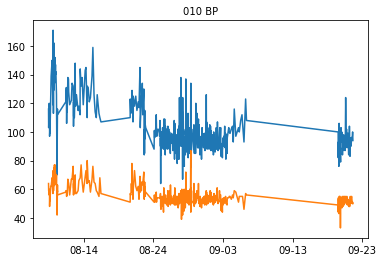

In [33]:
### example: plots all of the BP time series for all patients

from matplotlib.dates import DateFormatter
for ii in [9]: #range(6): #[0]:#range(len(patient_object_list)):
    patient = patient_object_list[ii]
    print(patient.ID)
    fig, ax = plt.subplots()
    plt.plot(patient.datenums_BP, patient.systolic)
    plt.plot(patient.datenums_BP, patient.diastolic)
    
    ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))
    ax.set_title(patient.ID + ' BP', fontdict={'fontsize': 10, 'fontweight': 'medium'})
    fig.savefig('BP_studyID_'+str(ii+1))

In [17]:
patient.datenums_BP.shape

(118,)

In [29]:
patient.ID

'001'

In [34]:
patient = patient_object_list[9]
DateNum_to_DateTime(patient.datenums_BP)

[datetime.datetime(2017, 8, 7, 22, 40, 0, 5, tzinfo=<DstTzInfo 'US/Eastern' EDT-1 day, 20:00:00 DST>),
 datetime.datetime(2017, 8, 7, 22, 40, 0, 5, tzinfo=<DstTzInfo 'US/Eastern' EDT-1 day, 20:00:00 DST>),
 datetime.datetime(2017, 8, 7, 23, 1, 59, 999996, tzinfo=<DstTzInfo 'US/Eastern' EDT-1 day, 20:00:00 DST>),
 datetime.datetime(2017, 8, 7, 23, 1, 59, 999996, tzinfo=<DstTzInfo 'US/Eastern' EDT-1 day, 20:00:00 DST>),
 datetime.datetime(2017, 8, 8, 0, 28, tzinfo=<DstTzInfo 'US/Eastern' EDT-1 day, 20:00:00 DST>),
 datetime.datetime(2017, 8, 8, 0, 28, tzinfo=<DstTzInfo 'US/Eastern' EDT-1 day, 20:00:00 DST>),
 datetime.datetime(2017, 8, 8, 0, 41, 0, 4, tzinfo=<DstTzInfo 'US/Eastern' EDT-1 day, 20:00:00 DST>),
 datetime.datetime(2017, 8, 8, 0, 41, 0, 4, tzinfo=<DstTzInfo 'US/Eastern' EDT-1 day, 20:00:00 DST>),
 datetime.datetime(2017, 8, 8, 0, 59, 59, 999997, tzinfo=<DstTzInfo 'US/Eastern' EDT-1 day, 20:00:00 DST>),
 datetime.datetime(2017, 8, 8, 0, 59, 59, 999997, tzinfo=<DstTzInfo 'US/Ea

In [18]:
patient

In [19]:
DateTimes = pd.DataFrame(DateNum_to_DateTime(patient.datenums_BP.tolist()), columns = ['DateTime'])

In [21]:
### example: plots all of the BP time series for all patients

from matplotlib.dates import DateFormatter
for ii in range(6): #[0]:#range(len(patient_object_list)):
    patient = patient_object_list[ii]
    
    BP_df = pd.DataFrame()
    BP_df['DateTime'] = DateNum_to_DateTime(patient.datenums_BP.tolist())
    BP_df['Systolic'] = patient.systolic
    BP_df['Diastolic'] = patient.diastolic
    BP_df.to_csv('BP_studyID_'+str(ii+1)+'.csv', index = False)


,DateTime
0,2017-07-06 20:46:59.999996-04:00
1,2017-07-06 20:46:59.999996-04:00
2,2017-07-06 23:04:59.999995-04:00
3,2017-07-06 23:04:59.999995-04:00
4,2017-07-07 06:00:00-04:00
...,...
113,2017-07-16 02:39:00.000005-04:00
114,2017-07-16 08:12:59.999997-04:00
115,2017-07-16 08:12:59.999997-04:00
116,2017-07-16 13:27:00.000001-04:00


In [ ]:
DateTimes.DateTime = DateTimes.DateTime.dt.tz_localize(None)

In [ ]:
DateTimes.head()

In [ ]:
### example: plots all of the BP time series for all patients

from matplotlib.dates import DateFormatter
for ii in [0]:#range(len(patient_object_list)):
    patient = patient_object_list[ii]
    
    fig, ax = plt.subplots()
    plt.plot(DateTimes, patient.systolic)
    plt.plot(DateTimes, patient.diastolic)
    
    ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))
    ax.set_title(patient.ID + ' BP', fontdict={'fontsize': 10, 'fontweight': 'medium'})